In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
from scipy.stats import ttest_1samp
from datetime import  timedelta

## Setup

In [3]:
start_date = '2018-01-01'
end_date = '2021-12-31'
time_period=50



stock = pd.read_csv('Data/Netflix Dataset.csv')
stock = stock[['Date', 'Adj Close', 'Volume']]
stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock[stock['Date'] >= start_date]
stock = stock[stock['Date'] <= end_date]



titles = pd.read_csv('Data/netflix_titles.csv')
titles = titles[['title', 'country', 'date_added']]



box_office = pd.read_csv('Data/boxoffice_data_2024.csv')
box_office = box_office[['Title', 'Gross']]
box_office['Gross'] = box_office['Gross'].str.replace(',', '')
box_office['Gross'] = box_office['Gross'].str.replace('$', '')
box_office['Gross'] = box_office['Gross'].astype(int)
box_office = box_office.sort_values('Gross', ascending=False)
box_office['Gross'] = box_office['Gross'].apply(lambda x: f"${x:,}")
box_office['rank'] = range(1, len(box_office) + 1)



revenue = pd.read_csv('Data/netflix_revenue_updated.csv')
revenue = revenue[['Date', 'Global Revenue', 'Netflix Streaming Memberships ']]
revenue['Date'] = pd.to_datetime(revenue['Date'])
revenue = revenue[revenue['Date'] >= start_date]
revenue = revenue[revenue['Date'] <= end_date]



countries = pd.read_csv('Data/all_weeks_countries.csv', encoding='windows-1252')
countries = countries[['country_name', 'week','weekly_rank', 'show_title', 'cumulative_weeks_in_top_10']]
countries = countries[countries['country_name'] == 'United States']
countries = countries.drop(columns = 'country_name')



merged_rank = pd.merge(titles, box_office, left_on='title', right_on='Title')
merged_rank = merged_rank.drop(columns=['Title', 'Gross'])
merged_rank = merged_rank.sort_values('rank', ascending=True)
merged_rank = merged_rank.drop(columns = ['country'])
merged_rank = merged_rank.reset_index(drop = True)
merged_rank['date_added'] = merged_rank['date_added'].str.strip()
merged_rank['date_added'] = pd.to_datetime(merged_rank['date_added'])

/tmp/ipykernel_2638/2316719367.py:33: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  revenue['Date'] = pd.to_datetime(revenue['Date'])


In [4]:
print(merged_rank, end='\n\n')

print(merged_rank.info())

                                              title date_added  rank
0                            Avengers: Infinity War 2018-12-25     5
1                                     Black Panther 2018-09-04    17
2     The Lord of the Rings: The Return of the King 2020-01-01    29
3                                             Joker 2018-08-02    36
4                                   The Jungle Book 2019-05-11    55
...                                             ...        ...   ...
1036                                 Sister, Sister 2020-09-01  7992
1037           Thelonious Monk: Straight, No Chaser 2019-11-01  8053
1038                                     The Family 2019-08-09  8094
1039                                      Champions 2021-06-19  8121
1040                                  Heartbreakers 2019-12-31  8125

[1041 rows x 3 columns]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  

In [5]:
print(revenue)

print(revenue.info())

         Date  Global Revenue  Netflix Streaming Memberships 
0  2019-03-31      4520992000                       148863000
1  2019-06-30      4923116000                       151562000
2  2019-09-30      5244905000                       158334000
3  2019-12-31      5467434000                       167090000
4  2020-03-31      5767691000                       182856000
5  2020-06-30      6148286000                       192947000
6  2020-09-30      6435637000                       195151000
7  2020-12-31      6644442000                       203663000
8  2021-03-31      7163282000                       207639000
9  2021-06-30      7341777000                       209180000
10 2021-09-30      7483467000                       213563000
11 2021-12-31      7709318000                       221844000
<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                  

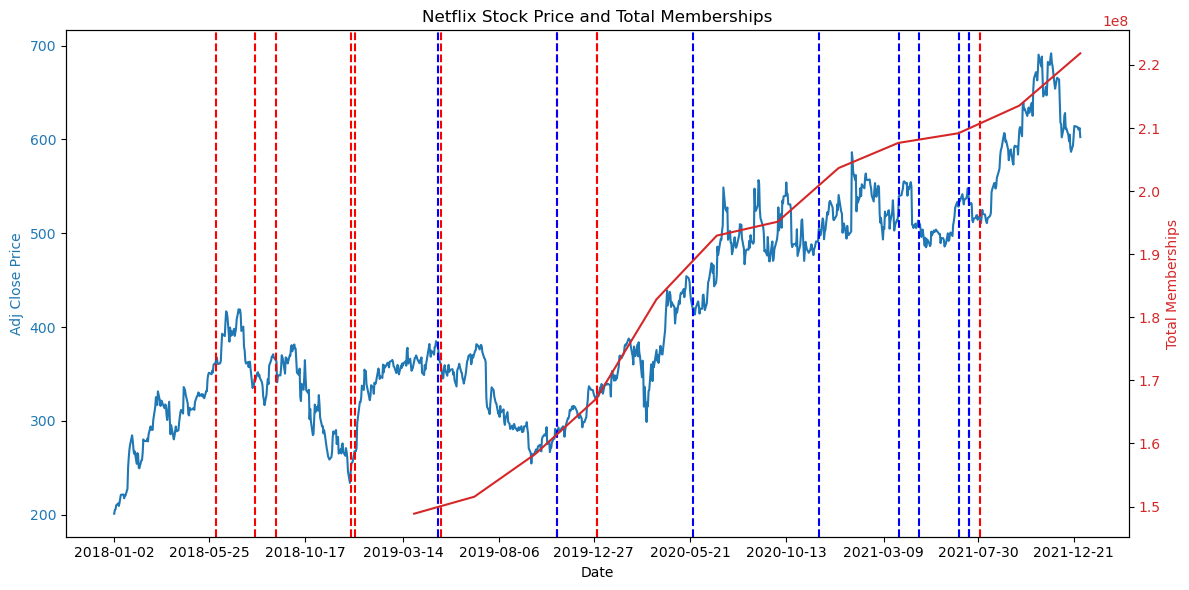

In [7]:
color_set = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot stock price on primary axis (left)
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Adj Close Price', color=color)
ax1.plot(stock['Date'].to_numpy(), stock['Adj Close'].to_numpy(), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Netflix Stock Price and Total Memberships')

# Add your vertical lines and spans to the primary axis
for i in range(19):
    date_added = pd.to_datetime(merged_rank['date_added'].iloc[i])
    if i % 10 == 0:
        color = color_set[i // 10 % 10]
    ax1.axvline(x=date_added, color=color, linestyle='--')
             
# Create secondary axis (right)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Total Memberships', color=color)
ax2.plot(revenue['Date'].to_numpy(), revenue['Netflix Streaming Memberships '].to_numpy(), color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Format x-axis ticks
time_period = len(stock['Date'])//10  # Adjust as needed for good spacing
ax1.set_xticks(stock['Date'][::time_period])
plt.xticks(rotation=45)  # Rotate dates for better readability

# Show plot
plt.tight_layout()
plt.show()

### --------------------------------------------------------------------------------

## Membership Regression Analysis

In [8]:
def transform_to_weekly_data(revenue_df):
    # Create weekly date range
    min_date = revenue_df['Date'].min()
    max_date = revenue_df['Date'].max()
    weekly_dates = pd.date_range(start=min_date, end=max_date, freq='W')
    weekly_df = pd.DataFrame({'Date': weekly_dates})
    
    # Merge and interpolate quarterly membership data
    weekly_df = pd.merge_asof(weekly_df.sort_values('Date'), 
                             revenue_df.sort_values('Date'),
                             on='Date',
                             direction='backward')
    weekly_df = weekly_df.fillna(method='ffill')
    weekly_df['Netflix Streaming Memberships '] = weekly_df['Netflix Streaming Memberships '].interpolate(method='linear')
    weekly_df['Membership_Change'] = weekly_df['Netflix Streaming Memberships '].diff()
    
    return weekly_df

def prepare_regression_data(movie_df, weekly_membership_df):
    regression_df = weekly_membership_df.copy()
    regression_df['MovieRelease'] = 0
    regression_df['BoxOfficeRank'] = np.nan
    regression_df['TitleReleased'] = ""
    
    # Mark weeks with movie releases and their box office ranks
    for week_date in regression_df['Date']:
        week_start = week_date - timedelta(days=6)
        movies_in_week = movie_df[(movie_df['date_added'] >= week_start) & 
                                (movie_df['date_added'] <= week_date)]
        
        if len(movies_in_week) > 0:
            regression_df.loc[regression_df['Date'] == week_date, 'MovieRelease'] = 1
            best_rank = movies_in_week['rank'].min()
            best_title = movies_in_week.loc[movies_in_week['rank'].idxmin(), 'title']
            regression_df.loc[regression_df['Date'] == week_date, 'BoxOfficeRank'] = best_rank
            regression_df.loc[regression_df['Date'] == week_date, 'TitleReleased'] = best_title
            
    regression_df['BoxOfficeRank'] = regression_df['BoxOfficeRank'].fillna(10000)
    regression_df = regression_df.dropna(subset=['Membership_Change'])
    
    return regression_df

def run_regression_model(regression_df):
    # Model 3: Interaction between release and rank
    regression_df['Release_Rank_Interaction'] = regression_df['MovieRelease'] * regression_df['BoxOfficeRank']
    X = sm.add_constant(regression_df[['MovieRelease', 'BoxOfficeRank', 'Release_Rank_Interaction']])
    y = regression_df['Membership_Change']
    return sm.OLS(y, X).fit()

def plot_box_office_rank_vs_membership(regression_df):
    # Filter for weeks with movie releases
    release_weeks = regression_df[regression_df['MovieRelease'] == 1]
    
    plt.figure(figsize=(10, 6))
    plt.scatter(release_weeks['BoxOfficeRank'], release_weeks['Membership_Change'])
    plt.title('Box Office Rank vs. Membership Change')
    plt.xlabel('Box Office Rank (lower is better)')
    plt.ylabel('Membership Change')
    plt.xscale('log')
    plt.grid(True)
    plt.show()

def run_analysis():
    # Load data
    movie_df, revenue_df = merged_rank, revenue
    
    # Transform and prepare data
    weekly_membership_df = transform_to_weekly_data(revenue_df)
    regression_df = prepare_regression_data(movie_df, weekly_membership_df)
    
    # Run regression model
    model = run_regression_model(regression_df)
    
    # Print statistical significance check
    print("\nStatistical Significance Check:")
    for var in ['MovieRelease', 'BoxOfficeRank', 'Release_Rank_Interaction']:
        pval = model.pvalues[var]
        significance = "Significant" if pval < 0.05 else "Not significant"
        print(f"{var}: {significance} (p={pval:.4f})")
    
    # Show the key plot
    plot_box_office_rank_vs_membership(regression_df)

/tmp/ipykernel_2638/3456841296.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weekly_df = weekly_df.fillna(method='ffill')



Statistical Significance Check:
MovieRelease: Significant (p=0.0006)
BoxOfficeRank: Not significant (p=0.5087)
Release_Rank_Interaction: Significant (p=0.0489)


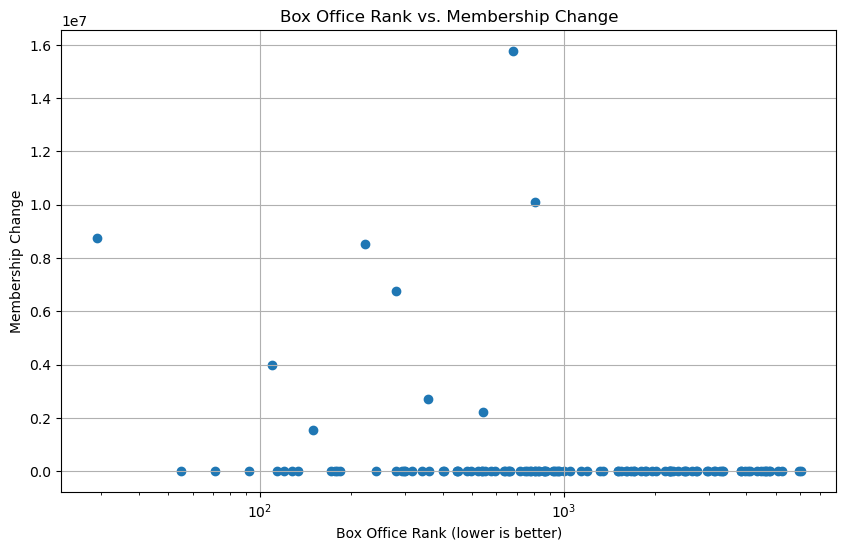

In [9]:
run_analysis()

### --------------------------------------------------------------------------------

## Correlation Test

Spearman Correlation: 0.064

Regression Results:
Coefficient (movie_releases): 0.096
P-value: 0.5967
R-squared: 0.032


/tmp/ipykernel_2638/1968391703.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Coefficient (movie_releases): {model.params[1]:.3f}")
/tmp/ipykernel_2638/1968391703.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"P-value: {model.pvalues[1]:.4f}")


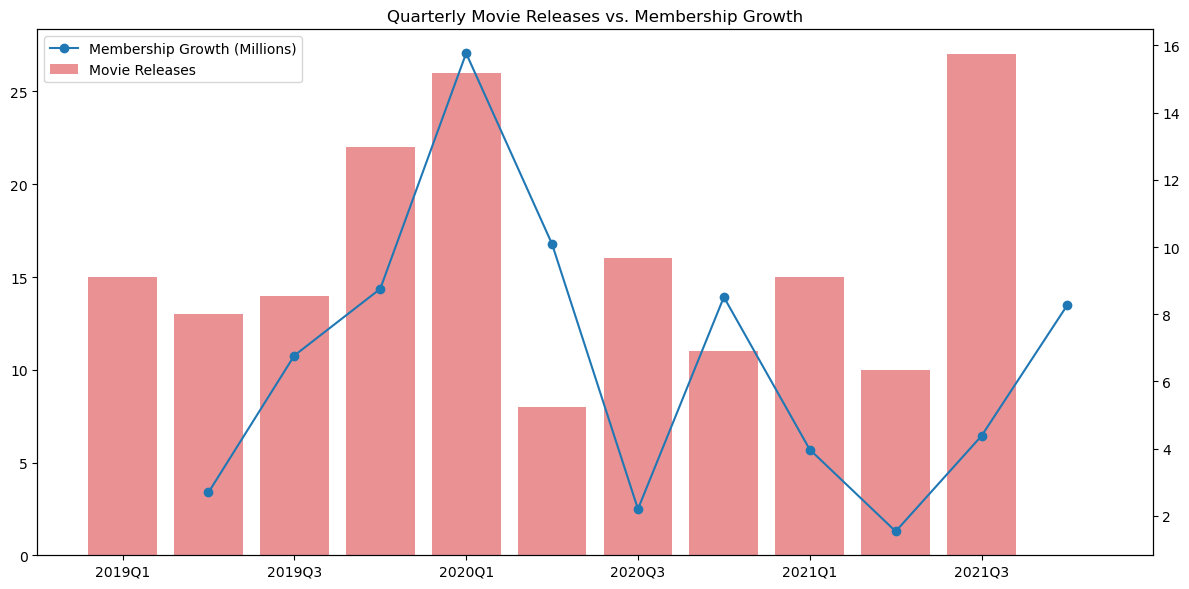

In [11]:
top_movies = merged_rank[merged_rank['rank'] <= 1000].copy()
top_movies['quarter'] = top_movies['date_added'].dt.to_period('Q')
movies_per_quarter = top_movies['quarter'].value_counts().sort_index()

revenue['quarter'] = pd.to_datetime(revenue['Date']).dt.to_period('Q')

df = revenue.merge(movies_per_quarter.rename('movie_releases'), 
                  left_on='quarter', 
                  right_index=True, 
                  how='left').fillna(0)

df['membership_growth'] = df['Netflix Streaming Memberships '].diff()
df['growth_millions'] = df['membership_growth'] / 1_000_000
df_clean = df.dropna(subset=['membership_growth']).copy()

# Correlation analysis
corr = df_clean[['movie_releases', 'growth_millions']].corr(method='spearman').iloc[0,1]
print(f"Spearman Correlation: {corr:.3f}\n")

# Regression analysis
X = sm.add_constant(df_clean['movie_releases'])
model = sm.OLS(df_clean['growth_millions'], X).fit()

print("Regression Results:")
print(f"Coefficient (movie_releases): {model.params[1]:.3f}")
print(f"P-value: {model.pvalues[1]:.4f}")
print(f"R-squared: {model.rsquared:.3f}")


plt.figure(figsize=(12, 6))
plt.bar(df['quarter'].astype(str).to_numpy(), df['movie_releases'].to_numpy(), alpha=0.5, color='tab:red', label='Movie Releases')
plt.twinx()
plt.plot(df['quarter'].astype(str).to_numpy(), df['growth_millions'].to_numpy(), marker='o', color='tab:blue', label='Membership Growth (Millions)')
plt.title('Quarterly Movie Releases vs. Membership Growth')
plt.xticks(rotation=45)
plt.gca().set_xticks(plt.gca().get_xticks()[::2]) 
lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = plt.gcf().axes[0].get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### --------------------------------------------------------------------------------

## Cumulative Abnormal Returns

In [14]:
def setup_event_study_params():
    return {
        'estimation_window': 120,
        'gap': 10,
        'event_window_pre': 10,
        'event_window_post': 10,
        'ticker': 'NFLX',
        'market_ticker': '^GSPC'
    }

def download_stock_data(movies_df, params):
    # Calculate date range with buffer
    earliest_date = movies_df['date_added'].min() - timedelta(days=params['estimation_window'] + params['gap'] + params['event_window_pre'] + 30)
    latest_date = movies_df['date_added'].max() + timedelta(days=params['event_window_post'] + 30)
    
    # Download and calculate returns
    stock_data = yf.download([params['ticker'], params['market_ticker']], 
                           start=earliest_date, end=latest_date, 
                           auto_adjust=False)
    return stock_data['Adj Close'].pct_change().dropna()

def calculate_abnormal_returns(movies_df, stock_returns, params):
    results = []
    
    for _, movie in movies_df.iterrows():
        event_date = movie['date_added']
        estimation_end = event_date - timedelta(days=params['gap'])
        estimation_start = estimation_end - timedelta(days=params['estimation_window'])
        event_start = event_date - timedelta(days=params['event_window_pre'])
        event_end = event_date + timedelta(days=params['event_window_post'])
        
        try:
            if estimation_start not in stock_returns.index or event_end not in stock_returns.index:
                continue
                
            # Market model estimation
            estimation_data = stock_returns.loc[estimation_start:estimation_end]
            X = sm.add_constant(estimation_data[params['market_ticker']])
            model = sm.OLS(estimation_data[params['ticker']], X).fit()
            
            # Calculate abnormal returns
            event_data = stock_returns.loc[event_start:event_end]
            X_event = sm.add_constant(event_data[params['market_ticker']])
            expected_returns = model.predict(X_event)
            abnormal_returns = event_data[params['ticker']] - expected_returns
            
            # Prepare results
            abnormal_returns = abnormal_returns.reset_index()
            abnormal_returns['days_from_event'] = (abnormal_returns['Date'] - event_date).dt.days
            abnormal_returns['CAR'] = abnormal_returns[0].cumsum()
            abnormal_returns['movie_title'] = movie['title']
            abnormal_returns['movie_rank'] = movie['rank']
            
            results.append(abnormal_returns)
        except Exception as e:
            print(f"Error processing {movie['title']}: {e}")
    
    return pd.concat(results) if results else pd.DataFrame()

def analyze_results(all_results, movies_df):
    avg_car = all_results.groupby('days_from_event')['CAR'].mean().reset_index()
    
    movies_df['rank_tier'] = pd.qcut(movies_df['rank'], 2, labels=['High', 'Low'])
    merged_results = all_results.merge(
        movies_df[['title', 'rank_tier']], 
        left_on='movie_title', 
        right_on='title',
        how='left'
    )
    car_by_tier = merged_results.groupby(['rank_tier', 'days_from_event'])['CAR'].mean().reset_index()
    
    return avg_car, car_by_tier

def plot_results(avg_car, car_by_tier):
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(avg_car['days_from_event'].to_numpy(), avg_car['CAR'].to_numpy())
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title('Average Cumulative Abnormal Returns')
    plt.xlabel('Days from Event')
    plt.ylabel('CAR')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    for tier in car_by_tier['rank_tier'].unique():
        data = car_by_tier[car_by_tier['rank_tier'] == tier]
        plt.plot(data['days_from_event'].to_numpy(), data['CAR'].to_numpy(), label=f'Rank: {tier}')
    
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title('CAR by Movie Rank Tier')
    plt.xlabel('Days from Event')
    plt.ylabel('CAR')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def statistical_tests(all_results):
    # Day 0 significance test
    day0_cars = all_results[all_results['days_from_event'] == 0]['CAR']
    t_stat, p_value = ttest_1samp(day0_cars, 0)
    print(f"Event day CAR - T-stat: {t_stat:.4f}, p-value: {p_value:.4f}")
    
    # Window analysis
    windows = [(-1, 1), (-3, 3), (-5, 5), (-10, 10)]
    print("\nWindow Analysis:")
    for start, end in windows:
        window_data = all_results[(all_results['days_from_event'] >= start) & 
                                (all_results['days_from_event'] <= end)]
        final_cars = window_data.groupby('movie_title')['CAR'].last()
        mean_car = final_cars.mean()
        t_stat, p_value = ttest_1samp(final_cars, 0)
        print(f"[{start},{end}]: Mean CAR={mean_car:.4f}, t-stat={t_stat:.4f}, p-value={p_value:.4f}")

def run_event_study():
    params = setup_event_study_params()
    stock_returns = download_stock_data(merged_rank, params)
    all_results = calculate_abnormal_returns(merged_rank, stock_returns, params)
    
    if not all_results.empty:
        avg_car, car_by_tier = analyze_results(all_results, merged_rank)
        plot_results(avg_car, car_by_tier)
        statistical_tests(all_results)
    else:
        print("No valid events to analyze")

[*********************100%***********************]  2 of 2 completed
/tmp/ipykernel_2638/1805631436.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  car_by_tier = merged_results.groupby(['rank_tier', 'days_from_event'])['CAR'].mean().reset_index()


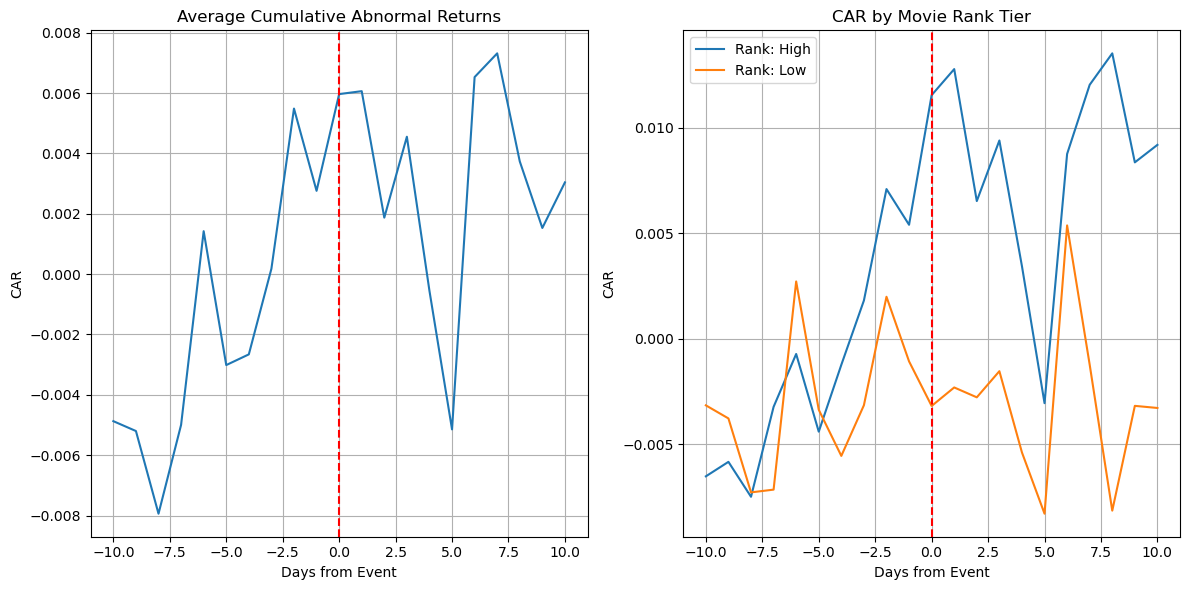

Event day CAR - T-stat: 2.0295, p-value: 0.0432

Window Analysis:
[-1,1]: Mean CAR=0.0043, t-stat=1.8996, p-value=0.0580
[-3,3]: Mean CAR=0.0051, t-stat=2.0205, p-value=0.0438
[-5,5]: Mean CAR=0.0003, t-stat=0.1052, p-value=0.9163
[-10,10]: Mean CAR=0.0035, t-stat=1.0504, p-value=0.2940


In [15]:
run_event_study()

### --------------------------------------------------------------------------------

## Release Window Analysis (Cumulative weeks)

#### Dropped for final presentation but used in midterm data presentation

In [16]:
start_date = '2021-06-01'
end_date = '2021-12-31'
time_period=50

stock = pd.read_csv('Data/Netflix Dataset.csv')
stock = stock[['Date', 'Adj Close', 'Volume']]
stock['Date'] = pd.to_datetime(stock['Date'])
stock = stock[stock['Date'] >= start_date]
stock = stock[stock['Date'] <= end_date]



titles = pd.read_csv('Data/netflix_titles.csv')
titles = titles[['title', 'country', 'date_added', 'director']]



box_office = pd.read_csv('Data/boxoffice_data_2024.csv')
box_office = box_office[['Title', 'Gross']]
box_office['Gross'] = box_office['Gross'].str.replace(',', '')
box_office['Gross'] = box_office['Gross'].str.replace('$', '')
box_office['Gross'] = box_office['Gross'].astype(int)
box_office = box_office.sort_values('Gross', ascending=False)
box_office['Gross'] = box_office['Gross'].apply(lambda x: f"${x:,}")
box_office['rank'] = range(1, len(box_office) + 1)



revenue = pd.read_csv('Data/netflix_revenue_updated.csv')
revenue = revenue[['Date', 'UCAN Streaming Revenue', 'UCAN Members', 'UCAN ARPU']]
revenue['Date'] = pd.to_datetime(revenue['Date'])
revenue = revenue[revenue['Date'] >= start_date]
revenue = revenue[revenue['Date'] <= end_date]



countries = pd.read_csv('Data/all_weeks_countries.csv', encoding='windows-1252')
countries = countries[['country_name', 'week','weekly_rank', 'show_title', 'cumulative_weeks_in_top_10']]
countries = countries[countries['country_name'] == 'United States']
countries = countries.drop(columns = 'country_name')


merged_rank = pd.merge(titles, box_office, left_on='title', right_on='Title')
merged_rank = merged_rank.drop(columns=['Title', 'Gross'])
merged_rank = pd.merge(merged_rank, countries, left_on='title', right_on='show_title')
merged_rank = merged_rank.sort_values('cumulative_weeks_in_top_10', ascending=True)
merged_rank = merged_rank.drop_duplicates(subset='title', keep='last')
merged_rank = merged_rank.drop(columns=['show_title', 'country'])
merged_rank = merged_rank.sort_values('rank')
merged_rank['date_added'] = pd.to_datetime(merged_rank['date_added'])
merged_rank['date_added'] = merged_rank['date_added'].dt.strftime('%Y-%m-%d')
merged_rank['week'] = pd.to_datetime(merged_rank['week'])
merged_rank['date_added'] = pd.to_datetime(merged_rank['date_added'])
merged_rank['date_diff'] = (merged_rank['week'] - merged_rank['date_added']).abs()
merged_rank = merged_rank[merged_rank['date_diff'] <= (merged_rank['cumulative_weeks_in_top_10'] * pd.Timedelta(days=7))]
merged_rank = merged_rank.drop(columns=['date_diff'])
merged_rank = merged_rank.reset_index(drop=True)

/tmp/ipykernel_2638/1993962259.py:31: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  revenue['Date'] = pd.to_datetime(revenue['Date'])


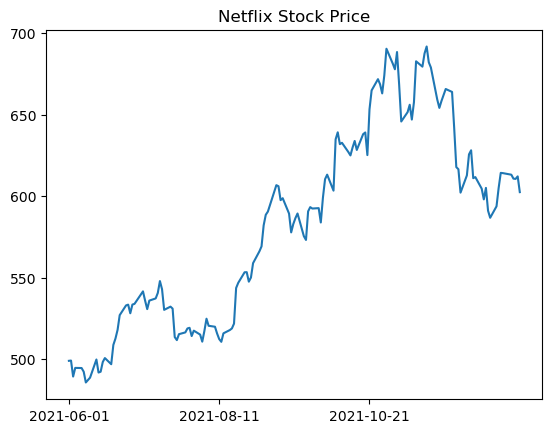

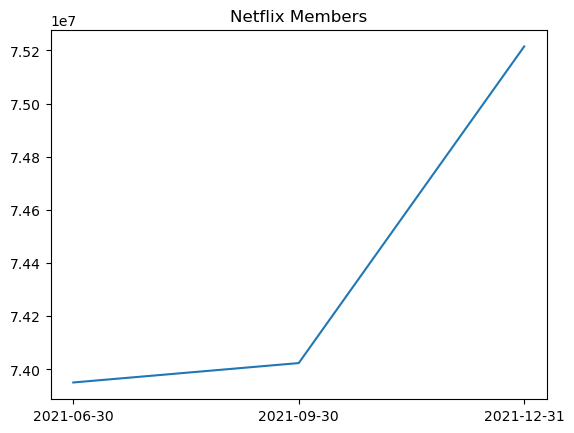

In [18]:
fig, ax = plt.subplots()
ax.plot(stock['Date'].to_numpy(), stock['Adj Close'].to_numpy())
ax.set_title('Netflix Stock Price')
plt.xticks(stock['Date'][::time_period])
plt.show()

fig, ax = plt.subplots()
ax.plot(revenue['Date'].to_numpy(), revenue['UCAN Members'].to_numpy())
ax.set_title('Netflix Members')
plt.xticks(revenue['Date'][::1])
plt.show()

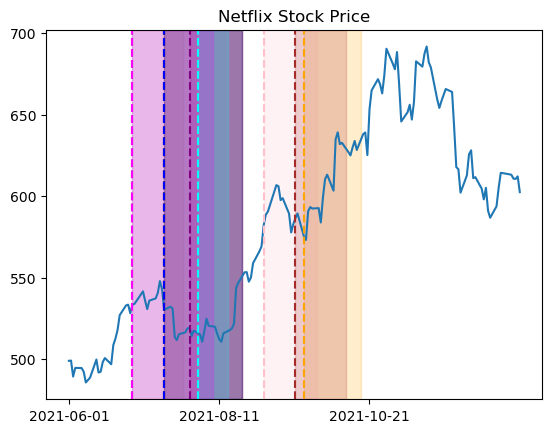

In [20]:
fig, ax = plt.subplots()
ax.plot(stock['Date'].to_numpy(), stock['Adj Close'].to_numpy())
ax.set_title('Netflix Stock Price')
plt.xticks(stock['Date'][::time_period])
colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink', 'brown', 'gray', 'cyan', 'magenta']
for i in range(10):
    date_added = pd.to_datetime(merged_rank['date_added'].iloc[i])
    plt.axvline(x=date_added, color=colors[i], linestyle='--')
    ax.axvspan(merged_rank['date_added'].iloc[i], merged_rank['week'].iloc[i] + 
            pd.Timedelta(days=merged_rank['cumulative_weeks_in_top_10'].iloc[i] * 7), color=colors[i], alpha=0.2)
plt.show()



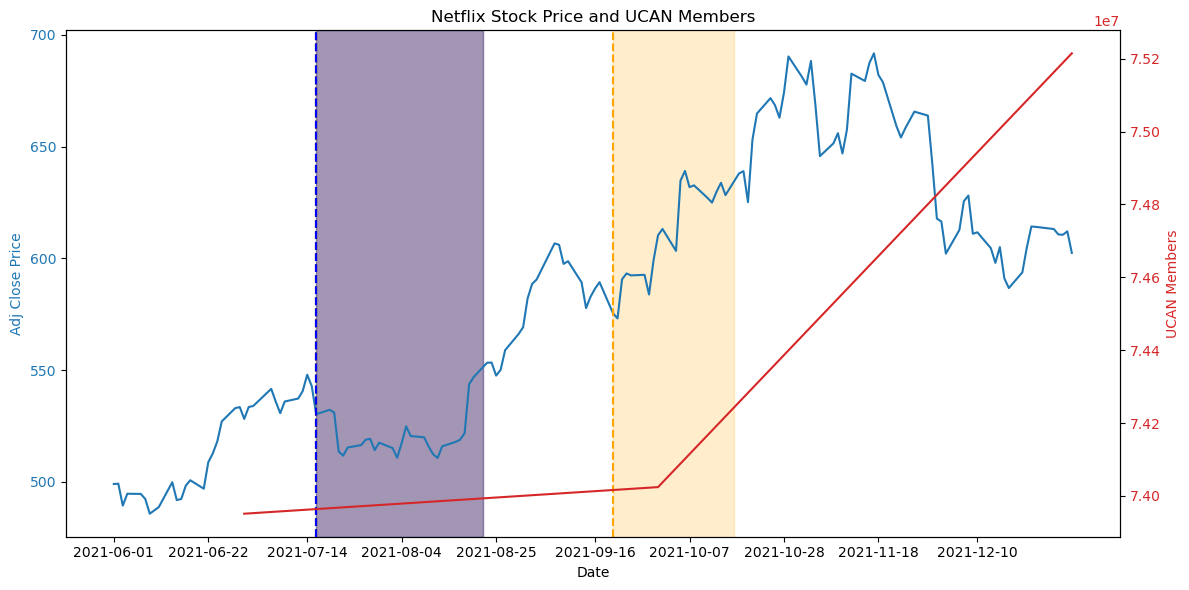

In [23]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot stock price on primary axis (left)
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Adj Close Price', color=color)
ax1.plot(stock['Date'].to_numpy(), stock['Adj Close'].to_numpy(), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Netflix Stock Price and UCAN Members')

# Add your vertical lines and spans to the primary axis
colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink', 'brown', 'gray', 'cyan', 'magenta']
for i in range(4):
    date_added = pd.to_datetime(merged_rank['date_added'].iloc[i])
    ax1.axvline(x=date_added, color=colors[i], linestyle='--')
    ax1.axvspan(merged_rank['date_added'].iloc[i], 
                merged_rank['week'].iloc[i] + pd.Timedelta(days=merged_rank['cumulative_weeks_in_top_10'].iloc[i] * 7), 
                color=colors[i], alpha=0.2)

# Create secondary axis (right)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('UCAN Members', color=color)
ax2.plot(revenue['Date'].to_numpy(), revenue['UCAN Members'].to_numpy(), color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Format x-axis ticks
time_period = len(stock['Date'])//10  # Adjust as needed for good spacing
ax1.set_xticks(stock['Date'][::time_period])
plt.xticks(rotation=45)  # Rotate dates for better readability

# Show plot
plt.tight_layout()
plt.show()